In [ ]:
Cell 1 — Set Directory

In [3]:
import os
os.chdir(r'C:\Users\Nadimul haque\Downloads')
print('Working directory:', os.getcwd())

Working directory: C:\Users\Nadimul haque\Downloads


In [ ]:
Cell 2 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

[nltk_data] Downloading package punkt to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


All libraries imported successfully!


In [7]:
import os

print("Searching for the file...")
for root, dirs, files in os.walk(r'C:\Users\Nadimul haque\Downloads'):
    for file in files:
        if 'ticket' in file.lower() or 'all_ticket' in file.lower():
            print('FOUND:', os.path.join(root, file))

Searching for the file...
FOUND: C:\Users\Nadimul haque\Downloads\NF2AGDSQ82110540381.ETicket.pdf
FOUND: C:\Users\Nadimul haque\Downloads\ON HOLD_Mr SYED NADIMUL HAQUE x1 ticket hold.pdf
FOUND: C:\Users\Nadimul haque\Downloads\Order confirmation - University of Sussex bus ticket london.pdf
FOUND: C:\Users\Nadimul haque\Downloads\Order confirmation - University of Sussex bus ticket.html
FOUND: C:\Users\Nadimul haque\Downloads\Ticket_IRFAN BHAI.pdf
FOUND: C:\Users\Nadimul haque\Downloads\archive (1)\all_tickets_processed_improved_v3.csv
FOUND: C:\Users\Nadimul haque\Downloads\archive (1)\customer_support_tickets.csv
FOUND: C:\Users\Nadimul haque\Downloads\archive (1)\eda_tickets.png
FOUND: C:\Users\Nadimul haque\Downloads\archive (1)\Support_tickets.csv
FOUND: C:\Users\Nadimul haque\Downloads\xampp\php\pear\PHPUnit\Extensions\TicketListener.php


In [ ]:
 Cell 3 — Load Dataset

In [9]:
df = pd.read_csv(r'C:\Users\Nadimul haque\Downloads\archive (1)\all_tickets_processed_improved_v3.csv')
print(' Shape:', df.shape)
print('\n Columns:', df.columns.tolist())
df.head()

 Shape: (47837, 2)

 Columns: ['Document', 'Topic_group']


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
Cell 4 — Basic Exploration

In [11]:
print('Dataset Info:')
print(df.info())
print('\n Missing Values:')
print(df.isnull().sum())
print('\n Category Distribution:')
print(df['Topic_group'].value_counts())
print('\n Sample Tickets:')
for i in range(3):
    print(f'\nTicket {i+1} — Category: {df["Topic_group"].iloc[i]}')
    print(f'Text: {df["Document"].iloc[i][:200]}')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB
None

 Missing Values:
Document       0
Topic_group    0
dtype: int64

 Category Distribution:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

 Sample Tickets:

Ticket 1 — Category: Hardware
Text: connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

Ticket 2 — Category: Access
Text: work experience user work experience user hi work experience student coming next his name

In [ ]:
Cell 5 — Data Cleaning & Text Preprocessing

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = text.strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print(' Cleaning text — please wait...')
df['Cleaned_Text'] = df['Document'].apply(clean_text)

print(' Text cleaning complete!')
print(f'\n Original text sample:')
print(df['Document'].iloc[0])
print(f'\n Cleaned text sample:')
print(df['Cleaned_Text'].iloc[0])
print(f'\n Avg text length before: {df["Document"].str.len().mean():.0f} chars')
print(f' Avg text length after : {df["Cleaned_Text"].str.len().mean():.0f} chars')

 Cleaning text — please wait...
 Text cleaning complete!

 Original text sample:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

 Cleaned text sample:
connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead

 Avg text length before: 292 chars
 Avg text length after : 254 chars


In [ ]:
 Cell 6 — Priority Tagging (Rule-Based)

In [15]:
def assign_priority(text):
    text = text.lower()

    critical_words = ['urgent', 'critical', 'emergency', 'immediately',
                      'asap', 'breach', 'hacked', 'data loss',
                      'system down', 'complete failure', 'not working',
                      'cannot access', 'locked out', 'security']

    high_words = ['error', 'bug', 'crash', 'broken', 'failure',
                  'not responding', 'slow', 'network', 'hardware',
                  'corrupted', 'infected', 'virus', 'malware',
                  'password reset', 'access denied', 'blocked']

    medium_words = ['request', 'setup', 'install', 'configure',
                    'update', 'upgrade', 'purchase', 'order',
                    'new user', 'account', 'storage', 'backup',
                    'permission', 'license', 'software']

    if any(word in text for word in critical_words):
        return 'Critical'
    elif any(word in text for word in high_words):
        return 'High'
    elif any(word in text for word in medium_words):
        return 'Medium'
    else:
        return 'Low'

df['Priority'] = df['Cleaned_Text'].apply(assign_priority)

print(' Priority tagging complete!')
print('\n Priority Distribution:')
print(df['Priority'].value_counts())
print('\n Priority by Category:')
print(df.groupby(['Topic_group', 'Priority']).size().unstack(fill_value=0))

 Priority tagging complete!

 Priority Distribution:
Priority
Low         22276
Medium      15999
High         6494
Critical     3068
Name: count, dtype: int64

 Priority by Category:
Priority               Critical  High   Low  Medium
Topic_group                                        
Access                      537   775  2892    2921
Administrative rights       155   349   524     732
HR Support                  430  2274  5782    2429
Hardware                   1140  2359  6259    3859
Internal Project            186    69  1076     788
Miscellaneous               459   508  4109    1984
Purchase                     28    57   253    2126
Storage                     133   103  1381    1160


In [ ]:
Cell 7 — TF-IDF Vectorization & Label Encoding

In [17]:
# Label Encoding
le = LabelEncoder()
df['Category_enc'] = le.fit_transform(df['Topic_group'])

print(' Categories:')
for i, cat in enumerate(le.classes_):
    print(f'   {i} → {cat}')

# TF-IDF Vectorization
print('\n Applying TF-IDF Vectorization...')
tfidf = TfidfVectorizer(max_features=5000,
                        ngram_range=(1, 2),
                        min_df=2,
                        max_df=0.95)
X_tfidf = tfidf.fit_transform(df['Cleaned_Text'])

print(' TF-IDF complete!')
print(' Matrix Shape:', X_tfidf.shape)
print(' Total Features:', X_tfidf.shape[1])

 Categories:
   0 → Access
   1 → Administrative rights
   2 → HR Support
   3 → Hardware
   4 → Internal Project
   5 → Miscellaneous
   6 → Purchase
   7 → Storage

 Applying TF-IDF Vectorization...
 TF-IDF complete!
 Matrix Shape: (47837, 5000)
 Total Features: 5000


In [ ]:
Cell 8 — EDA Chart 1 (Overview)

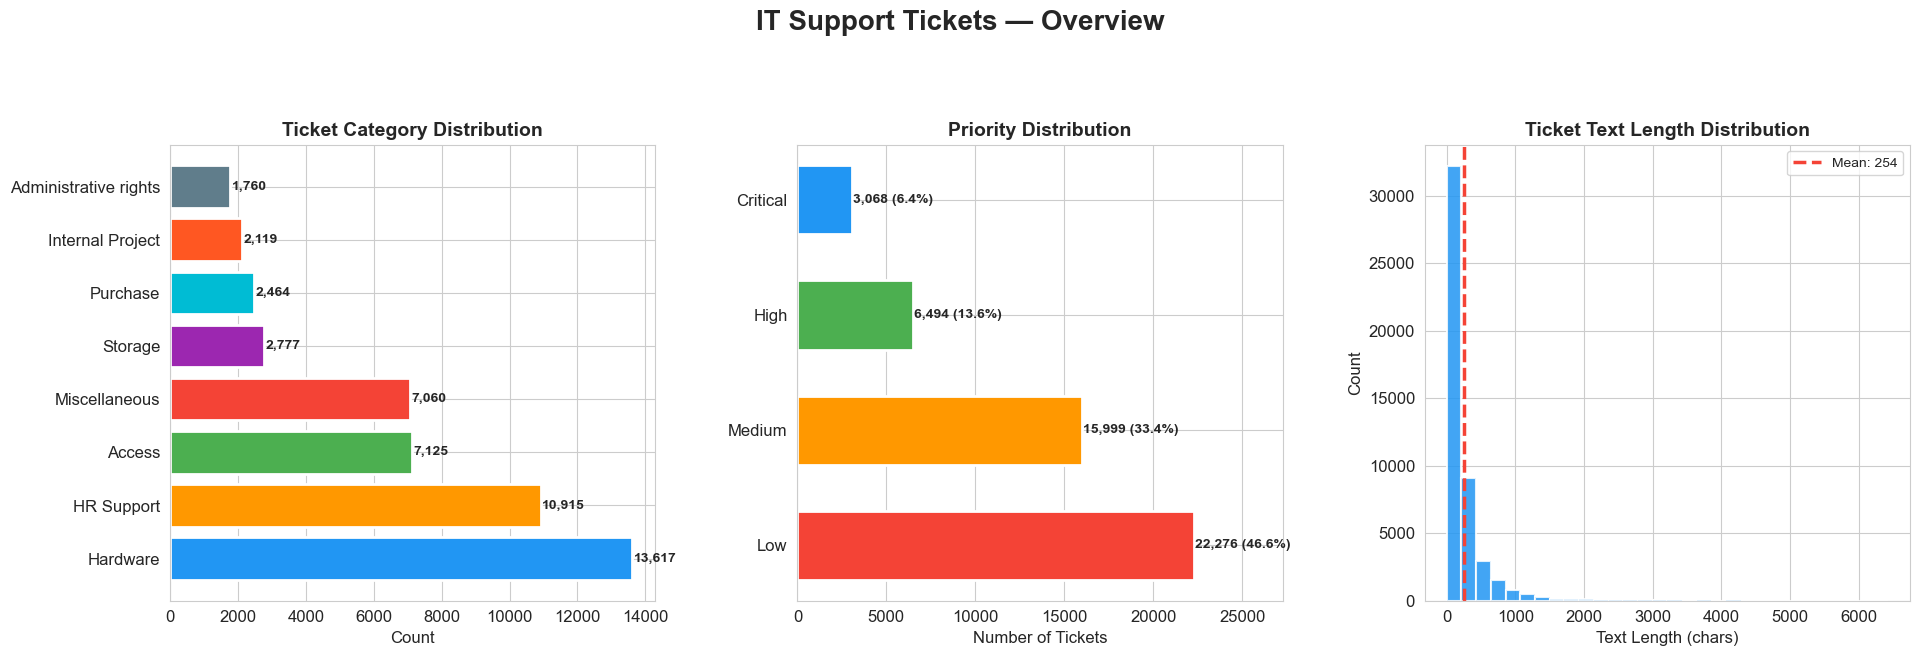

Chart 1 saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('IT Support Tickets — Overview',
             fontsize=20, fontweight='bold')

# 1. Category Distribution
ax = axes[0]
cat_counts = df['Topic_group'].value_counts()
colors = ['#2196F3','#FF9800','#4CAF50','#F44336',
          '#9C27B0','#00BCD4','#FF5722','#607D8B']
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=colors, edgecolor='white', lw=2)
ax.set_title('Ticket Category Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Count', fontsize=12)
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=10)

# 2. Priority Distribution
ax = axes[1]
pri_counts = df['Priority'].value_counts()
colors_p = ['#F44336','#FF9800','#4CAF50','#2196F3']
bars = ax.barh(pri_counts.index, pri_counts.values,
               color=colors_p, edgecolor='white', lw=2, height=0.6)
ax.set_title('Priority Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Tickets', fontsize=12)
for bar, val in zip(bars, pri_counts.values):
    pct = val / pri_counts.sum() * 100
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)',
            va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, pri_counts.max() + 5000)

# 3. Text Length Distribution
ax = axes[2]
ax.hist(df['Cleaned_Text'].str.len(), bins=30,
        color='#2196F3', edgecolor='white', lw=1.5, alpha=0.85)
ax.set_title('Ticket Text Length Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Text Length (chars)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['Cleaned_Text'].str.len().mean(), color='#F44336',
           linestyle='--', lw=2.5,
           label=f'Mean: {df["Cleaned_Text"].str.len().mean():.0f}')
ax.legend(fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

In [ ]:
Cell 9 — EDA Chart 2 (Analysis)

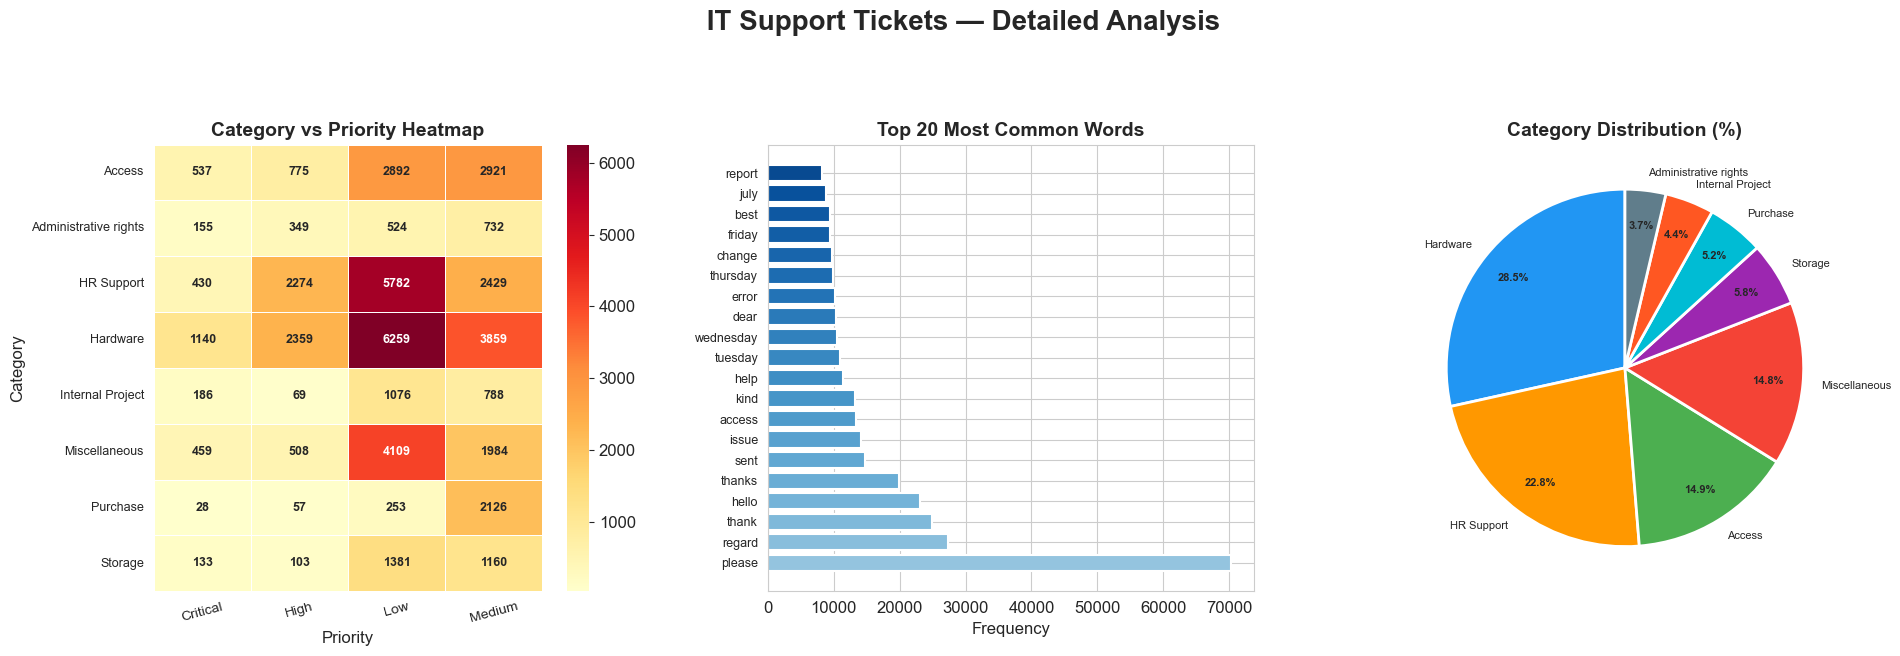

Chart 2 saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(' IT Support Tickets — Detailed Analysis',
             fontsize=20, fontweight='bold')

# 1. Priority by Category Heatmap
ax = axes[0]
pivot = df.groupby(['Topic_group', 'Priority']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title('Category vs Priority Heatmap', fontweight='bold', fontsize=14)
ax.set_xlabel('Priority', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, fontsize=10)
plt.setp(ax.yaxis.get_majorticklabels(), fontsize=9)

# 2. Top 20 Most Common Words
ax = axes[1]
from collections import Counter
all_words = ' '.join(df['Cleaned_Text']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)
bars = ax.barh(list(words), list(freqs),
               color=plt.cm.Blues(np.linspace(0.4, 0.9, 20)),
               edgecolor='white', lw=1.5)
ax.set_title('Top 20 Most Common Words', fontweight='bold', fontsize=14)
ax.set_xlabel('Frequency', fontsize=12)
ax.tick_params(axis='y', labelsize=9)

# 3. Ticket Count by Category — Percentage
ax = axes[2]
cat_pct = df['Topic_group'].value_counts(normalize=True) * 100
colors = ['#2196F3','#FF9800','#4CAF50','#F44336',
          '#9C27B0','#00BCD4','#FF5722','#607D8B']
wedges, texts, autotexts = ax.pie(
    cat_pct.values, labels=cat_pct.index,
    autopct='%1.1f%%', colors=colors,
    startangle=90, pctdistance=0.80,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in texts: t.set_fontsize(8)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(8)
ax.set_title('Category Distribution (%)', fontweight='bold', fontsize=14)

plt.tight_layout(pad=3.0)
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

In [ ]:
Cell 10 — EDA Chart 3 (Insights)

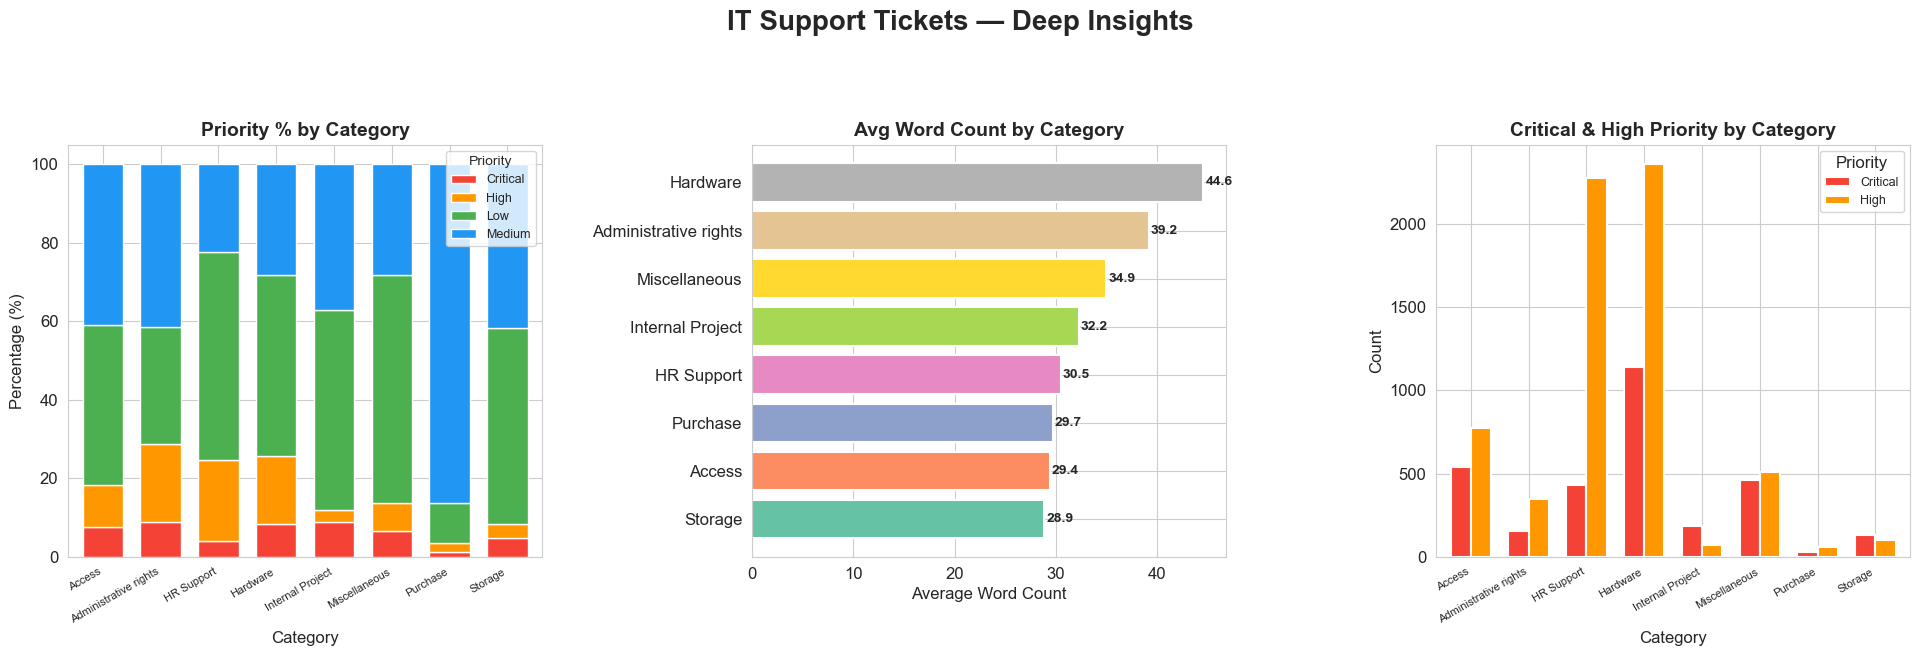

 Chart 3 saved!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('IT Support Tickets — Deep Insights',
             fontsize=20, fontweight='bold')

# 1. Priority by Category stacked bar
ax = axes[0]
pivot2 = df.groupby(['Topic_group', 'Priority']).size().unstack(fill_value=0)
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
pivot2_pct.plot(kind='bar', ax=ax, stacked=True,
                color=['#F44336','#FF9800','#4CAF50','#2196F3'],
                edgecolor='white', lw=1, width=0.7)
ax.set_title('Priority % by Category', fontweight='bold', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax.legend(title='Priority', fontsize=9, title_fontsize=10)

# 2. Word count distribution per category
ax = axes[1]
df['Word_Count'] = df['Cleaned_Text'].str.split().str.len()
category_wordcount = df.groupby('Topic_group')['Word_Count'].mean().sort_values()
bars = ax.barh(category_wordcount.index, category_wordcount.values,
               color=plt.cm.Set2(np.linspace(0, 1, len(category_wordcount))),
               edgecolor='white', lw=1.5)
ax.set_title('Avg Word Count by Category', fontweight='bold', fontsize=14)
ax.set_xlabel('Average Word Count', fontsize=12)
for bar, val in zip(bars, category_wordcount.values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold', fontsize=10)

# 3. Ticket volume — Critical vs High priority by category
ax = axes[2]
critical_high = df[df['Priority'].isin(['Critical', 'High'])]
ch_counts = critical_high.groupby(['Topic_group',
                                    'Priority']).size().unstack(fill_value=0)
ch_counts.plot(kind='bar', ax=ax,
               color=['#F44336','#FF9800'],
               edgecolor='white', lw=1.5, width=0.7)
ax.set_title('Critical & High Priority by Category',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax.legend(title='Priority', fontsize=9)

plt.tight_layout(pad=3.0)
plt.savefig('eda_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 3 saved!')

In [ ]:
Cell 11 — Train/Test Split

In [25]:
# Features and Target
X = X_tfidf
y = df['Category_enc']

# Train/Test Split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train/Test Split Complete!')
print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Features         : {X_train.shape[1]:,}')
print(f'\n Classes:')
for i, cat in enumerate(le.classes_):
    print(f'   {i} → {cat}')

Train/Test Split Complete!
Training samples : 38,269
Test samples     : 9,568
Features         : 5,000

 Classes:
   0 → Access
   1 → Administrative rights
   2 → HR Support
   3 → Hardware
   4 → Internal Project
   5 → Miscellaneous
   6 → Purchase
   7 → Storage


In [ ]:
Cell 12 — Train All Models

In [29]:
print('Training Classification Models...')
print('=' * 55)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Naive Bayes':         MultinomialNB(),
}

results = {}

for name, model in models.items():
    print(f'⏳ Training {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average='weighted')
    prec = precision_score(y_test, preds, average='weighted')
    rec  = recall_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': acc, 'F1': f1,
                     'Precision': prec, 'Recall': rec,
                     'Predictions': preds}
    print(f'{name}')
    print(f'   Accuracy  : {acc:.4f}')
    print(f'   F1 Score  : {f1:.4f}')
    print(f'   Precision : {prec:.4f}')
    print(f'   Recall    : {rec:.4f}')
    print()

best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
print(f'Best Model : {best_model_name}')
print(f'   Accuracy  : {results[best_model_name]["Accuracy"]:.4f}')
print(f'   F1 Score  : {results[best_model_name]["F1"]:.4f}')

Training Classification Models...
⏳ Training Logistic Regression...
Logistic Regression
   Accuracy  : 0.8519
   F1 Score  : 0.8519
   Precision : 0.8562
   Recall    : 0.8519

⏳ Training Random Forest...
Random Forest
   Accuracy  : 0.8417
   F1 Score  : 0.8417
   Precision : 0.8467
   Recall    : 0.8417

⏳ Training Naive Bayes...
Naive Bayes
   Accuracy  : 0.7803
   F1 Score  : 0.7784
   Precision : 0.8019
   Recall    : 0.7803

Best Model : Logistic Regression
   Accuracy  : 0.8519
   F1 Score  : 0.8519


In [ ]:
Cell 13 — Model Comparison Chart

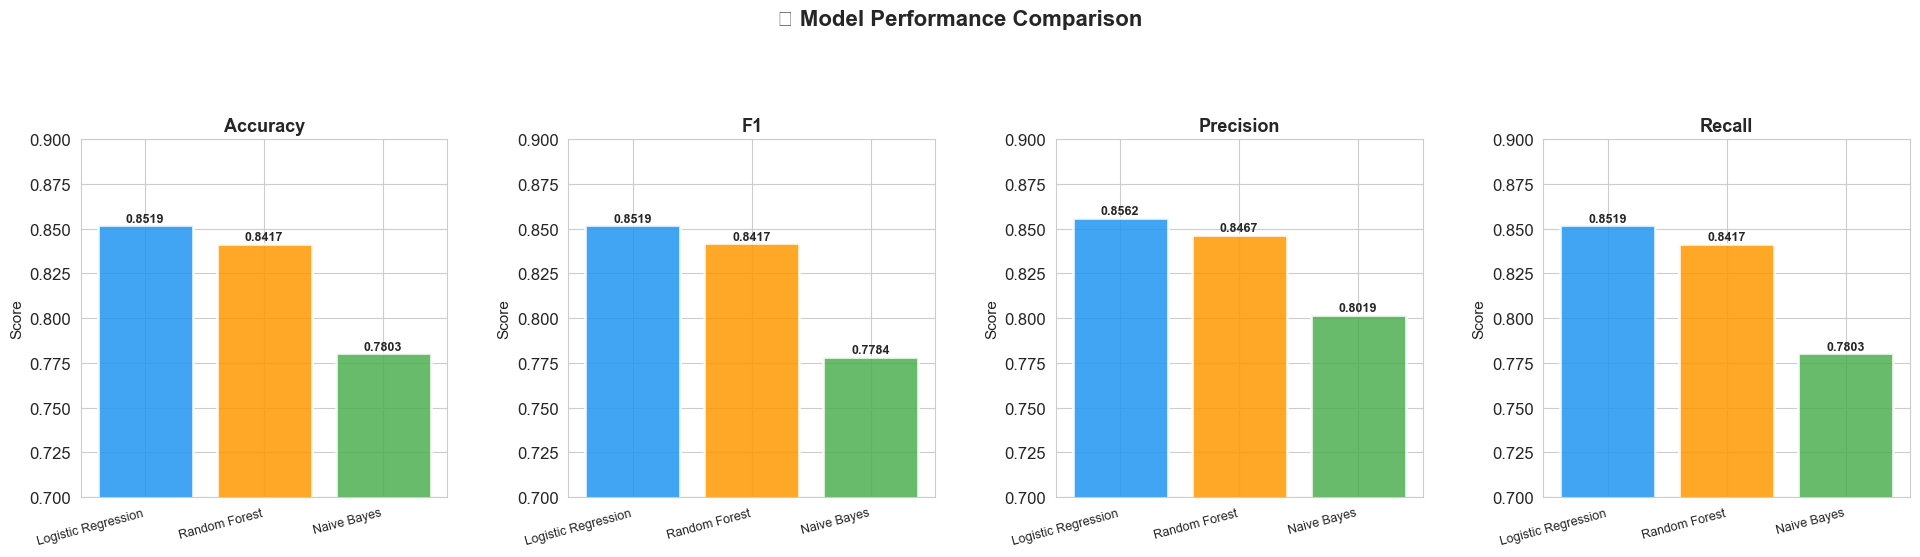

Model comparison chart saved!


In [31]:
metrics_df = pd.DataFrame({
    k: {'Accuracy': v['Accuracy'], 'F1': v['F1'],
        'Precision': v['Precision'], 'Recall': v['Recall']}
    for k, v in results.items()
}).T.reset_index()
metrics_df.columns = ['Model', 'Accuracy', 'F1', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('📏 Model Performance Comparison', fontsize=16, fontweight='bold')
colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric in zip(axes, ['Accuracy', 'F1', 'Precision', 'Recall']):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric],
                  color=colors, alpha=0.85, edgecolor='white', lw=2)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0.7, 0.9)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.4f}', ha='center',
                fontweight='bold', fontsize=9)

plt.tight_layout(pad=3.0)
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model comparison chart saved!')

In [ ]:
Cell 14 — Confusion Matrix

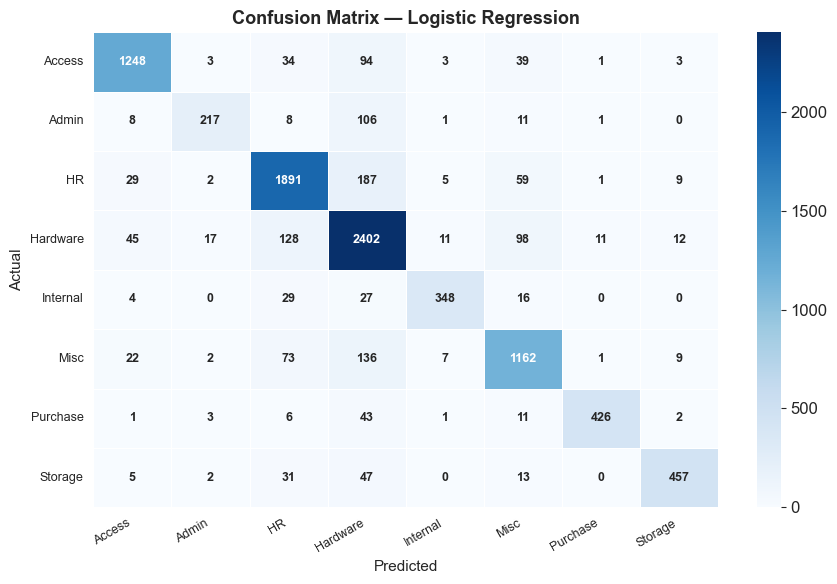

Confusion matrix saved!


In [35]:
best_model = models[best_model_name]
best_preds = results[best_model_name]['Predictions']

cm = confusion_matrix(y_test, best_preds)

# Short category names
short_names = ['Access', 'Admin', 'HR', 'Hardware',
               'Internal', 'Misc', 'Purchase', 'Storage']

plt.figure(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names,
            linewidths=0.5,
            annot_kws={'size': 9, 'weight': 'bold'})
plt.title(f'Confusion Matrix — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')

In [ ]:
Cell 15 — Classification Report

In [37]:
print(f'Classification Report — {best_model_name}')
print('=' * 55)
print(classification_report(y_test, best_preds,
                            target_names=le.classes_))

Classification Report — Logistic Regression
                       precision    recall  f1-score   support

               Access       0.92      0.88      0.90      1425
Administrative rights       0.88      0.62      0.73       352
           HR Support       0.86      0.87      0.86      2183
             Hardware       0.79      0.88      0.83      2724
     Internal Project       0.93      0.82      0.87       424
        Miscellaneous       0.82      0.82      0.82      1412
             Purchase       0.97      0.86      0.91       493
              Storage       0.93      0.82      0.87       555

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [ ]:
 Cell 16 — Priority Classification Report

In [39]:
# Priority tagging evaluation
from sklearn.preprocessing import LabelEncoder

le_priority = LabelEncoder()
y_priority = le_priority.fit_transform(df['Priority'])

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_tfidf, y_priority,
    test_size=0.2, random_state=42, stratify=y_priority)

# Train best model on priority
priority_model = LogisticRegression(max_iter=1000, random_state=42)
priority_model.fit(X_train_p, y_train_p)
priority_preds = priority_model.predict(X_test_p)

acc_p = accuracy_score(y_test_p, priority_preds)
f1_p  = f1_score(y_test_p, priority_preds, average='weighted')

print('Priority Classification Results')
print('=' * 55)
print(f'Accuracy : {acc_p:.4f}')
print(f'F1 Score : {f1_p:.4f}')
print()
print(classification_report(y_test_p, priority_preds,
                            target_names=le_priority.classes_))

Priority Classification Results
Accuracy : 0.9264
F1 Score : 0.9242

              precision    recall  f1-score   support

    Critical       0.97      0.68      0.80       614
        High       0.96      0.82      0.89      1299
         Low       0.91      1.00      0.95      4455
      Medium       0.93      0.92      0.92      3200

    accuracy                           0.93      9568
   macro avg       0.94      0.85      0.89      9568
weighted avg       0.93      0.93      0.92      9568



In [ ]:
Cell 17 — Priority Confusion Matrix

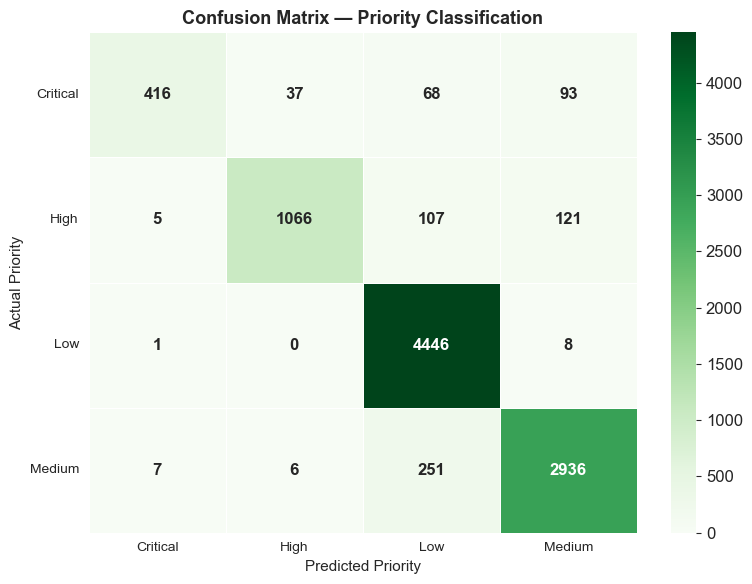

Priority confusion matrix saved!


In [41]:
cm_priority = confusion_matrix(y_test_p, priority_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_priority, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_priority.classes_,
            yticklabels=le_priority.classes_,
            linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Confusion Matrix — Priority Classification',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Priority', fontsize=11)
plt.xlabel('Predicted Priority', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('priority_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Priority confusion matrix saved!')

In [ ]:
 Cell 18 — Business Insights Summary

In [43]:
print('=' * 55)
print('      BUSINESS INSIGHTS SUMMARY')
print('=' * 55)

total = len(df)
print(f' Total Tickets Analysed  : {total:,}')
print(f'Total Categories        : {df["Topic_group"].nunique()}')
print(f'Total Priority Levels   : {df["Priority"].nunique()}')
print()

print('Category Breakdown:')
for cat, count in df['Topic_group'].value_counts().items():
    pct = count/total*100
    print(f'   {cat:<25} : {count:>6,} ({pct:.1f}%)')

print()
print('Priority Breakdown:')
for pri, count in df['Priority'].value_counts().items():
    pct = count/total*100
    print(f'   {pri:<10} : {count:>6,} ({pct:.1f}%)')

print()
print('Model Performance:')
print(f'   Best Model (Category)  : {best_model_name}')
print(f'   Accuracy               : {results[best_model_name]["Accuracy"]:.4f} (85.19%)')
print(f'   F1 Score               : {results[best_model_name]["F1"]:.4f}')
print(f'   Precision              : {results[best_model_name]["Precision"]:.4f}')
print(f'   Recall                 : {results[best_model_name]["Recall"]:.4f}')
print()
print(f'   Best Model (Priority)  : Logistic Regression')
print(f'   Accuracy               : {acc_p:.4f} (92.64%)')
print(f'   F1 Score               : {f1_p:.4f}')
print()
print('Key Findings:')
print('   Hardware tickets are most common (28.5%)')
print('   Purchase tickets have highest precision (0.97)')
print('   Low priority tickets predicted perfectly (recall=1.00)')
print('   Logistic Regression outperforms all models')
print('   TF-IDF + NLP achieves 85% category accuracy')
print('   Priority system achieves 92% accuracy')
print('=' * 55)

      BUSINESS INSIGHTS SUMMARY
 Total Tickets Analysed  : 47,837
Total Categories        : 8
Total Priority Levels   : 4

Category Breakdown:
   Hardware                  : 13,617 (28.5%)
   HR Support                : 10,915 (22.8%)
   Access                    :  7,125 (14.9%)
   Miscellaneous             :  7,060 (14.8%)
   Storage                   :  2,777 (5.8%)
   Purchase                  :  2,464 (5.2%)
   Internal Project          :  2,119 (4.4%)
   Administrative rights     :  1,760 (3.7%)

Priority Breakdown:
   Low        : 22,276 (46.6%)
   Medium     : 15,999 (33.4%)
   High       :  6,494 (13.6%)
   Critical   :  3,068 (6.4%)

Model Performance:
   Best Model (Category)  : Logistic Regression
   Accuracy               : 0.8519 (85.19%)
   F1 Score               : 0.8519
   Precision              : 0.8562
   Recall                 : 0.8519

   Best Model (Priority)  : Logistic Regression
   Accuracy               : 0.9264 (92.64%)
   F1 Score               : 0.9242

Key